# Analyze data exported to excel from the LC/MS
This notebook will extract and plot m/z spectrum data exported from Advion DataExpress, and highlight some [common background peaks](https://ccc.bc.edu/content/dam/bc1/top-tier/research/VPR/research-facilities/fisher-chemical-poster.pdf). To export data, hit "Export Peaks to Excel" in DataExpress, and select "Spectrum".

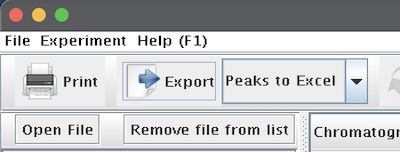


This will export *all* the peaks from every file you have open. This notebook can handle single or multiple spectra.

## How to use this notebook:
1. Process your LCMS data with Advion DataExpress and export as described above.
2. Create a CSV file with the information below:
|Column Name|Explanation|
|---|---|
|`sample_id`|The sample ID from the MassExpress sample list (you should be able to copy/paste these from MassExpress)|
|`MolWt`|The molecular weight of the compound|
2. Upload your files to the colab instance
- Click the folder icon on the left toolbar then drag your input file into the folder area
3. Replace the example path with your file's path
- Right click on your file and click "copy path"
- make sure it's enclosed in the quotes when you paste it
4. Run each cell to create your plots
- click the round circle with arrow next to the cell or hit shift+enter when your cursor is anywhere in the cell
- you can do single and manually enter the compound info, or skip straight to multiple and upload a CSV with the compound info
5. Download the saved files locally
- All files will be deleted shortly after you close the notebook instance
- If you can't see the new files, click the refresh folder icon at the top of the folder area
- You can right click and copy or save a plot
- Alternatively, follow


# Plot the spectra

Cloning into 'smdc_process_data'...
remote: Enumerating objects: 250, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 250 (delta 10), reused 15 (delta 5), pack-reused 226 (from 1)
Receiving objects: 100% (250/250), 53.47 MiB | 5.66 MiB/s, done.
Resolving deltas: 100% (128/128), done.
CPU times: user 1.16 s, sys: 40.2 ms, total: 1.2 s
Wall time: 11.5 s


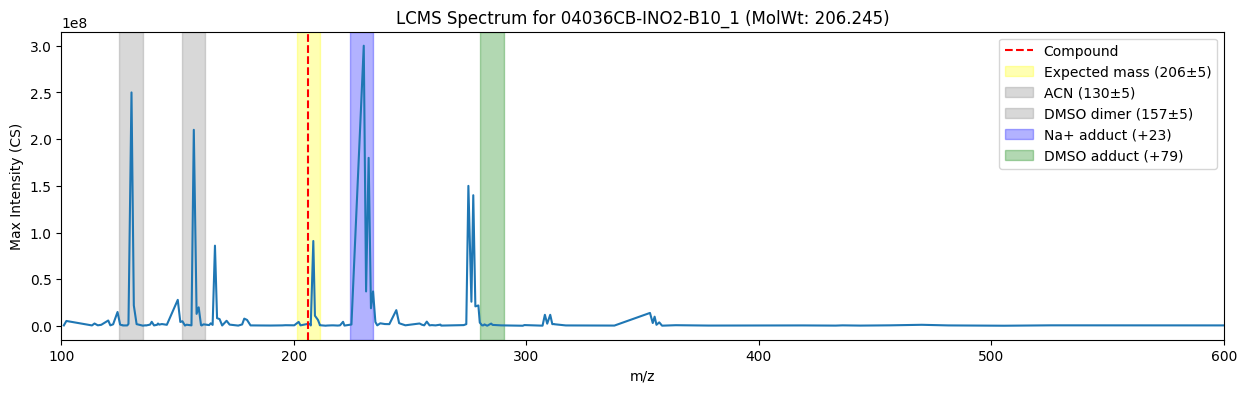

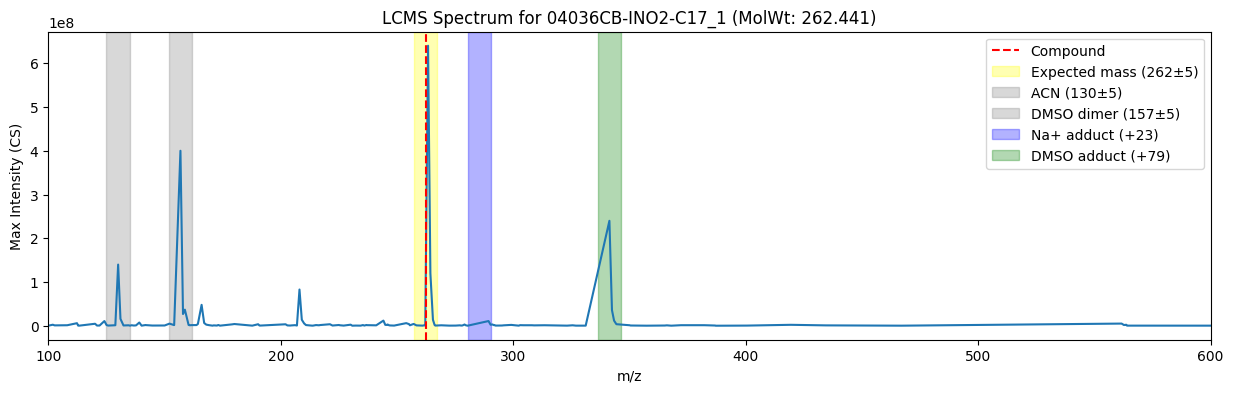

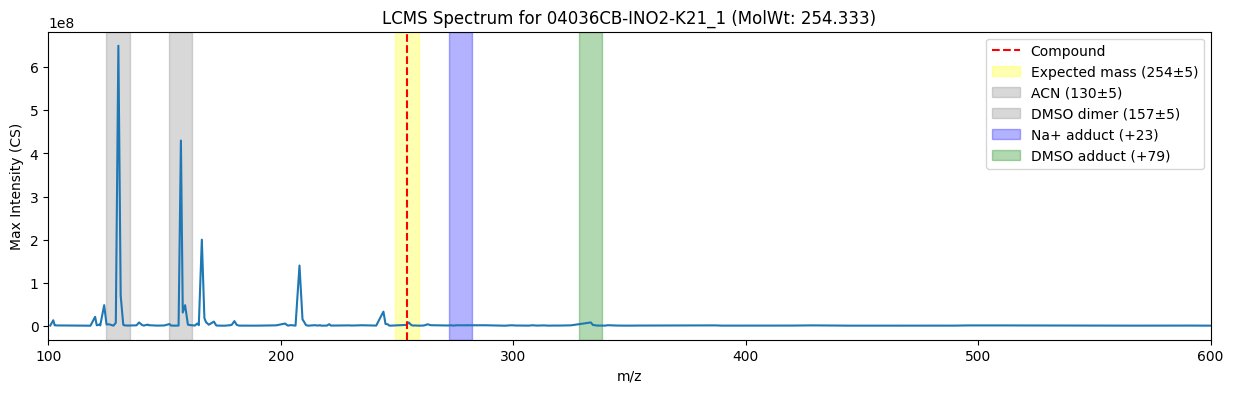

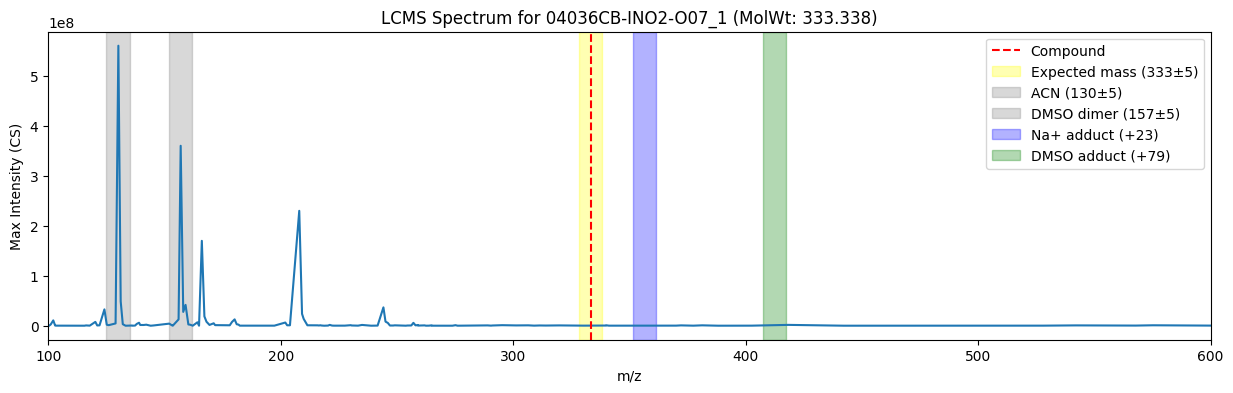

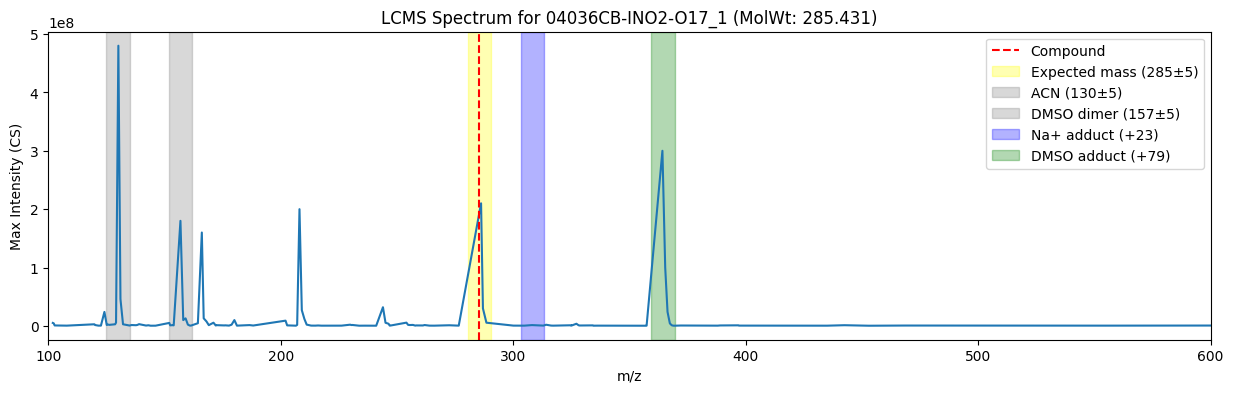

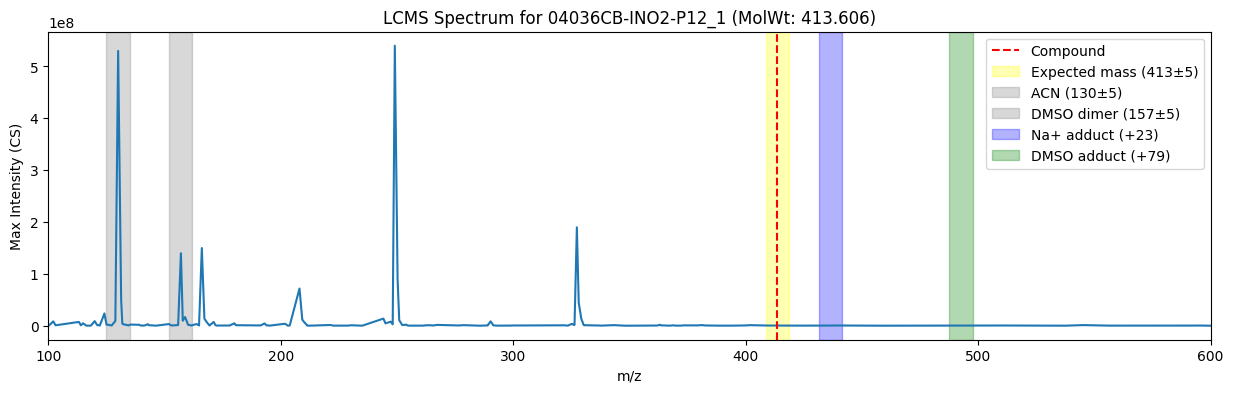

In [10]:
%%time
import os
import shutil # Import shutil for rmtree
if os.path.exists("/content/smdc_process_data"):
  shutil.rmtree("/content/smdc_process_data") # Use rmtree to remove non-empty directory
!git clone https://github.com/Small-Molecule-Discovery-Center/smdc_process_data.git
import sys
sys.path.append('/content/smdc_process_data')
import pandas as pd
from process_data import analyze_lcms as al

###################################
# # PASTE YOUR FILE NAMES BELOW # #
###################################
spectrum_file = "/content/smdc_process_data/data/example_LCMS_spectrum_data.xlsx"
info_file = "/content/smdc_process_data/data/example_LCMS_compound_info.csv"
###################################

data_df=al.read_lcms_results(infile=spectrum_file, kind="spectrum")
info_df=pd.read_csv(info_file)

# plot each spectra
for sample_id in info_df.sample_id.unique():
    al.plot_lcms_spectrum(info_df, data_df, sample_id, save=False) # change to True if you want to save as png's instead of output them on screen